In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Generate fake data to experiment with
np.random.seed(42)
X = np.random.randn (100, 5)
y = np.random.randint(0, 2, size=100)

# Split the data into train and test sets BEFORE fitting any transformers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a professional pipeline that keeps scaling and modeling contained
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

# Train the entire workflow securely (prevents test data leakage)
pipeline.fit(X_train, y_train)

# Evaluate the model cleanly
train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)

print(f'--- Pipeline Workflow Summary ---')
print(f'Training Accuracy: {train_acc:.2%}')
print(f'Testing Accuracy: {test_acc:.2%}')
print('\n[Depth Note]: By using this Pipeline, the StandardScaler calculates parameters ')
print('STRICTLY from X_train. X_test remains completely unseen until evaluation.')

--- Pipeline Workflow Summary ---
Training Accuracy: 61.25%
Testing Accuracy: 35.00%

[Depth Note]: By using this Pipeline, the StandardScaler calculates parameters 
STRICTLY from X_train. X_test remains completely unseen until evaluation.


## Part 2: The "Manual" Way (What We Did Before) revisiting the TITANIC DATASET.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Basic feature engineering and cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode())[0]

df = df.drop('Cabin', axis=1)

X = df.drop(['Survived', 'Name', 'Ticket', 'PassengerId'], axis=1)
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify feature types
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# Manual Preprocessing
scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train[numeric_features])
X_test_scaled_num = scaler.transform(X_test[numeric_features])


In [ ]:
# --- Manual Preprocessing (Continued) ---
encoder = OneHotEncoder(handle_unknown='ignore')
X_train_encoded_cat = encoder.fit_transform(X_train[categorical_features])
X_test_encoded_cat = encoder.transform(X_test[categorical_features])

# Combine preprocessed features
X_train_processed = np.hstack((X_train_scaled_num, X_train_encoded_cat.toarray()))
X_test_processed = np.hstack((X_test_scaled_num, X_test_encoded_cat.toarray()))

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_processed, y_train)
y_pred = model.predict(X_test_processed)

# Evaluate model
print(f'Accuracy (Manual Method): {accuracy_score(y_test, y_pred):.2%}')


Accuracy (Manual Method): 80.45%


Part 3: The "Pipeline" Way

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

# Create pipeline from numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Create a pipeline for catagorical features
catagorical_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

# Use ColumnTransformer to apply different transformers to different columns
preprocessor = make_column_transformer(
    (numeric_transformer, ['Age', 'Fare', 'SibSp', 'Parch']),
    (catagorical_transformer, ['Pclass', 'Sex', 'Embarked'])
)

# Create the final, full pipeline
final_pipeline = make_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

# Fit and evaluate the entire pipeline in one step!
final_pipeline.fit(X_train, y_train)
y_pred_pipeline = final_pipeline.predict(X_test)

print(f'Accuracy (Pipeline Method): {accuracy_score(y_test, y_pred_pipeline):.2%}')

Accuracy (Pipeline Method): 80.45%


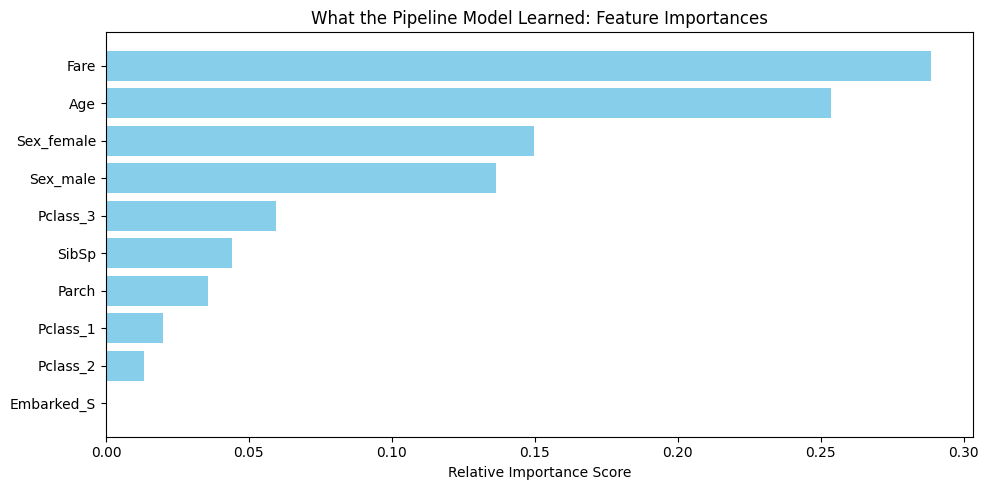

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Extract the trained RandomForest model directly from the pipeline object
trained_rf = final_pipeline.named_steps['randomforestclassifier']

# Extract the newly generated feature names from the catagorical encoder station
encoded_cat_features = final_pipeline.named_steps['columntransformer']\
.named_transformers_['pipeline-2']\
.named_steps['onehotencoder']\
.get_feature_names_out(['Pclass', 'Sex', 'Embarked'])

importances = trained_rf.feature_importances_

all_features = ['Age', 'Fare', 'SibSp', 'Parch'] + list (encoded_cat_features)

# Sort for a clean display plot
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title('What the Pipeline Model Learned: Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd
import numpy as np

# Save the complete pipeline architecture and trained weights into a single file
model_filename = 'titanic_pipeline_model.pkl'
joblib.dump(final_pipeline, model_filename)

print(f"Box Success: Entire ML pipeline successfully exported to '{model_filename}'")

# Simulate deploying this on a new server by reading the file back in
deployed_pipeline = joblib.load(model_filename)
print('Plug Success: Deployed pipeline loaded back into memory.')

# Create a brand new passenger profile to test deployment
new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['female'],
    'Age': [np.nan],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [8.05],
    'Embarked': ['S']
})

# Predict instantly using the loaded object
prediction = deployed_pipeline.predict(new_passenger)
survival_status = 'Survived Congratulation' if prediction[0] == 1 else 'Did Not Survive'

print(f'Prediction for new passenger: {survival_status}')
print('[Depth Note]: This single file contains the median imputer, feature scale, ')
print('one-hot encoder structural maps, and the random forest weights all inside one box.')

Box Success: Entire ML pipeline successfully exported to 'titanic_pipeline_model.pkl'
Plug Success: Deployed pipeline loaded back into memory.
Prediction for new passenger: Did Not Survive
[Depth Note]: This single file contains the median imputer, feature scale, 
one-hot encoder structural maps, and the random forest weights all inside one box.


        **REFLECTIVE KNOWLEDGE CHECK**


1. Code comparison: Look at the \"Manual Way\" versus the \Pipeline Way\". What are the three biggest advantages you see in using the
Pipeline approach?
***Basically nonmessy variable tracking: It completely gets rid of the clutter. There is no need constantly create and keep track of temporary arrays like X_train_scaled, X_test_scaled, X_train_encoded, or X_test_encoded. Zero copy-paste mistakes because it runs everything automatically in sequence, therefore you won't accidentally apply your scaling parameters to the wrong dataset or mixup the ordering of your columns.This is a very clean code that condenses dozens of lines of individual preprocessing steps down into a single, organized workflow block. So if you want to change out your machine learning model later, you only have to change one single line.


2. Data Leakage Explained: In the manual code, we used scaler.fit_transform()` on the training data but only `scaler.transform()` on the test data. Why was this distinction crucial? How does the Pipeline automatically handle this for you?

It is crucial because `.fit_transform()` calculates patterns from the data-like finding the exact average or standard deviation- and then applies it. If you run `.fit_transform()` on your test data, your scaler calculates new averages based on the test set, which means information from the future "leaks" into your model. That is cheating! You only want to learn patterns from the training data. The Pipeline handles this automatically by knowing whether you are training or testing: when you call `.fit()`, it automatically fits the transformers only on the training split, and when you call `.predict()`, it safely applies those pre-learned rules `(.transform())` to the unseen test data without mixing them up.


3. Extending the Pipeline: Imagine you wanted to add a PCA step to reduce dimensionality *after* scaling and encoding but *before* the `RandomForestClassifier`. How would you modify your `final_pipeline` object to include this step? (You don't need to write the full code, just describe where you would add `PCA()`.)

I would add `PCA()` as a new step right inside the `make_pipeline` function for our `final_pipeline`. I would place it as a comma-seperated item right after the preprocessor step(which does all the scaling and encoding) and right before the `RandonForestClassifier` step. This sets up an assembly line where the data gets cleaned and scaled first, gets compressed by PCA second, and gets handed to the Random Forest model last.


4. Real-World Value: You are handing your model over to another team to deploy into a web application. Why is giving them the single `final_pipeline` object  much safer and more reliable than giving them the 5 seperate objects (`scaler`, `model`, etc.) from the manual approach?

Handing over a single pipeline object is like giving the deployment team a completely built, closed-hood car- they just have to put gas in it(input the raw data) and it drives (outputs the prediction). If you give them 5 seperate objects, you are handing them a box of loose car parts and expecting them to rebuild the entire assembly line inside their web app. If they make a single mistake-like scaling the data before imputing missing values, or forgetting to encode a column- the application will crash or give completely broken predictions.